#Imports and Liabraries

In [1]:
import os
import math
import numpy as np
import random
from PIL import Image,ImageEnhance

# Keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense,Flatten,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import  VGG16,MobileNetV2,EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.utils import shuffle
from tensorflow.keras.layers import BatchNormalization

#Load Datasets

In [3]:
import os
import numpy as np
from pathlib import Path
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

train_dir = Path(r"E:\Pneumonia\train")
test_dir = Path(r"E:\Pneumonia\test")

classes = ['NORMAL', 'PNEUMONIA']


train_paths = []
train_labels = []

for label in classes:
    class_dir = train_dir / label

    for image in os.listdir(class_dir):
        train_paths.append(str(class_dir / image))
        train_labels.append(label)


test_paths = []
test_labels = []

for label in classes:
    class_dir = test_dir / label

    for image in os.listdir(class_dir):
        test_paths.append(str(class_dir / image))
        test_labels.append(label)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths,
    train_labels,
    test_size=0.20,
    random_state=42,
    stratify=train_labels
)

# Shuffle training and validation data
train_paths, train_labels = shuffle(
    train_paths,
    train_labels,
    random_state=42
)

val_paths, val_labels = shuffle(
    val_paths,
    val_labels,
    random_state=42
)

# Shuffle test data
test_paths, test_labels = shuffle(
    test_paths,
    test_labels,
    random_state=42
)



print("Training:")
print("NORMAL:", train_labels.count("NORMAL"))
print("PNEUMONIA:", train_labels.count("PNEUMONIA"))
print("Total:", len(train_paths))

print("\nValidation:")
print("NORMAL:", val_labels.count("NORMAL"))
print("PNEUMONIA:", val_labels.count("PNEUMONIA"))
print("Total:", len(val_paths))

print("\nTest:")
print("NORMAL:", test_labels.count("NORMAL"))
print("PNEUMONIA:", test_labels.count("PNEUMONIA"))
print("Total:", len(test_paths))

Training:
NORMAL: 1073
PNEUMONIA: 3099
Total: 4172

Validation:
NORMAL: 268
PNEUMONIA: 776
Total: 1044

Test:
NORMAL: 234
PNEUMONIA: 390
Total: 624


#Data Visualisation

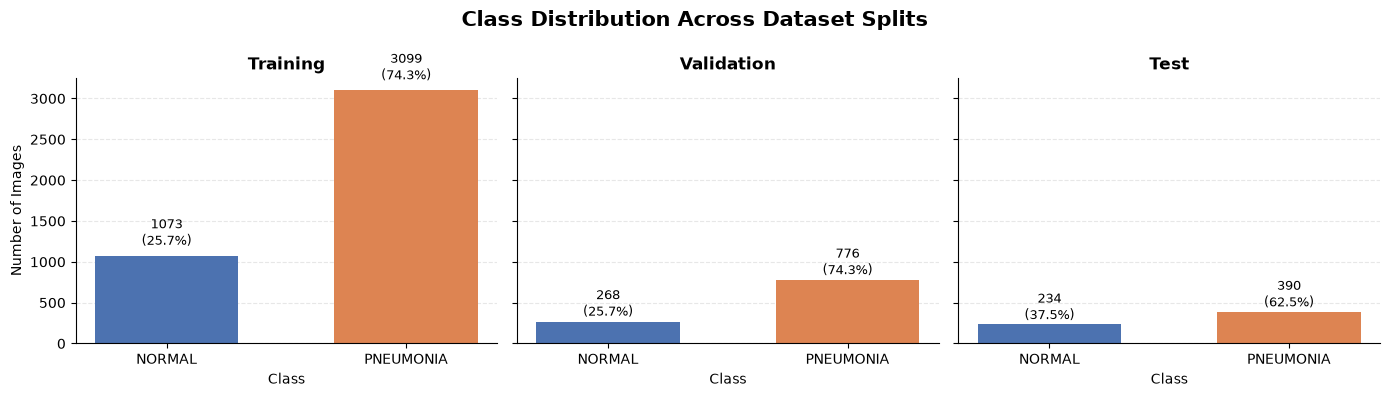

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

splits = ['Training', 'Validation', 'Test']
split_labels = {
    'Training': train_labels,
    'Validation': val_labels,
    'Test': test_labels
}

df_counts = pd.DataFrame(
    [
        {
            'split': split,
            'class': label,
            'count': split_labels[split].count(label)
        }
        for split in splits
        for label in classes
    ]
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colors = ['#4C72B0', '#DD8452']

for ax, split in zip(axes, splits):
    subset = df_counts[df_counts['split'] == split]
    total = subset['count'].sum()

    bars = ax.bar(
        subset['class'],
        subset['count'],
        color=colors,
        width=0.6
    )

    ax.set_title(split, fontsize=12, fontweight='bold')
    ax.set_xlabel('Class')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

    for bar, count in zip(bars, subset['count']):
        percentage = count / total * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            count + total * 0.02,
            f'{count}\n({percentage:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=9
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Number of Images')
fig.suptitle(
    'Class Distribution Across Dataset Splits',
    fontsize=15,
    fontweight='bold'
 )

plt.tight_layout()
plt.show()


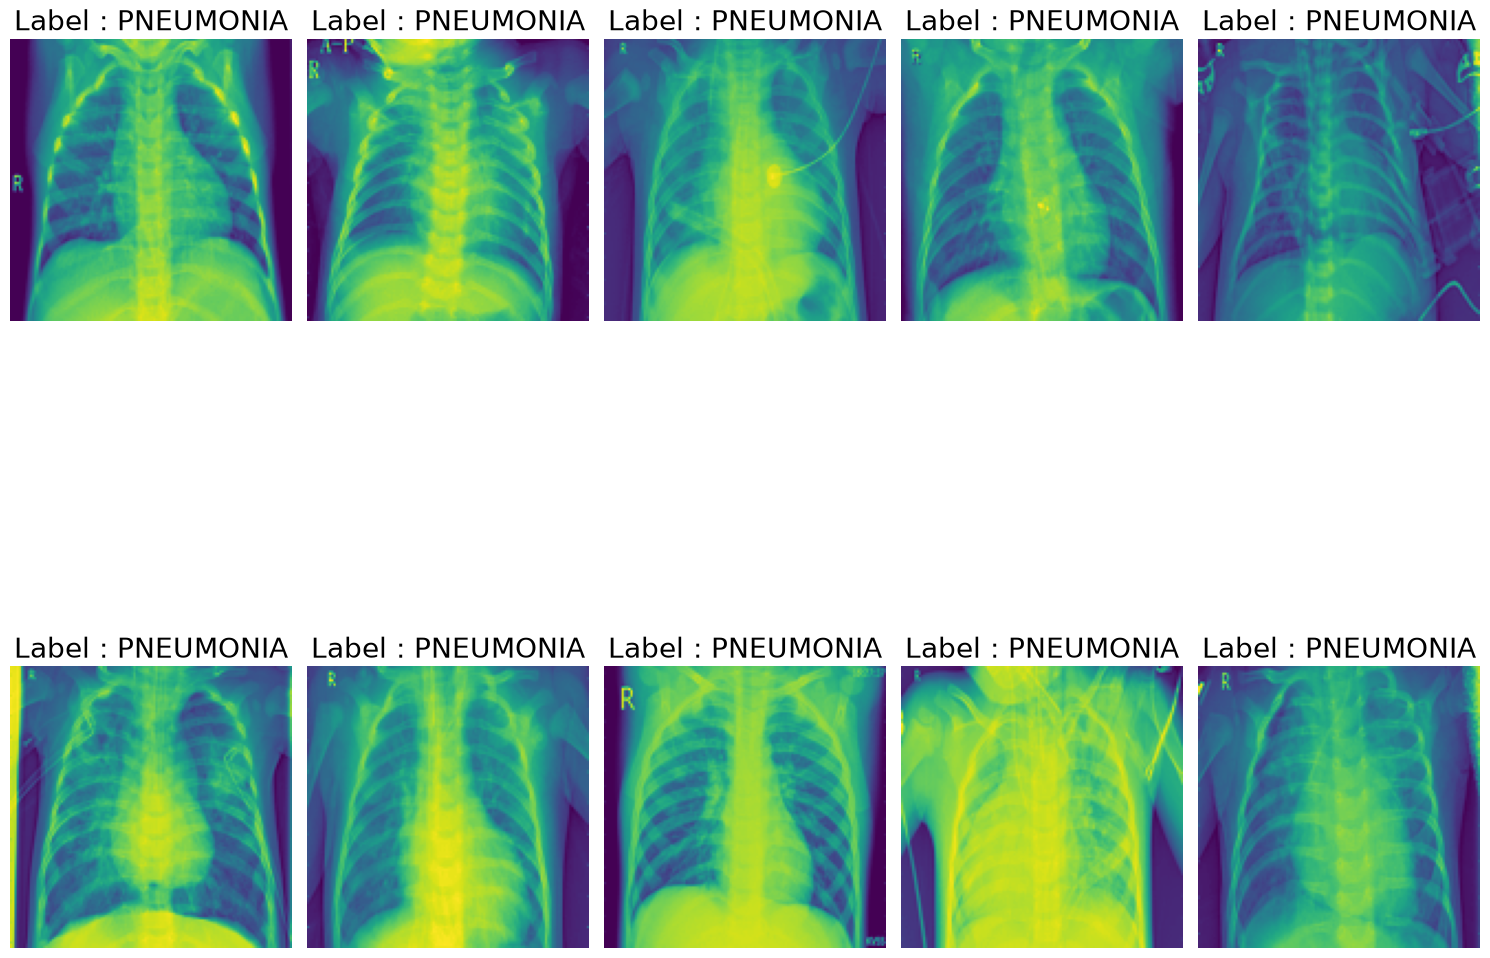

In [5]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

random_indices = random.sample(range(len(train_paths)),10)


fig,axes = plt.subplots(2,5, figsize= (15,16))
axes = axes.ravel()

for i,idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((128,128))

  # dispaly images

  axes[i].imshow(img)
  axes[i].axis("off")
  axes[i].set_title(f"Label : {train_labels[idx]}" , fontsize=20)

plt.tight_layout()
plt.show()


#Image preprocessing

In [25]:
"""# Image preprocessing"""

from tensorflow.keras.applications.vgg16 import preprocess_input

def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.9, 1.1))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.9, 1.1))

    image = img_to_array(image)
    image = preprocess_input(image)
    return image.astype(np.float32)


def open_images(paths):
    images = []

    for path in paths:
        image = load_img(
            path,
            target_size=(IMAGE_SIZE, IMAGE_SIZE),
            color_mode='rgb'
        )
        images.append(augment_image(image))

    return np.asarray(images, dtype=np.float32)



label_mapping = {
    'NORMAL': 0,
    'PNEUMONIA': 1
}

def encode_label(labels):
    encoded = [label_mapping[label] for label in labels]
    return np.asarray(encoded, dtype=np.int32)


def open_images_no_aug(paths):
    images = []

    for path in paths:
        image = load_img(
            path,
            target_size=(IMAGE_SIZE, IMAGE_SIZE),
            color_mode='rgb'
        )
        image = img_to_array(image)
        image = preprocess_input(image)
        images.append(image)

    return np.asarray(images, dtype=np.float32)


def datagen(paths, labels, batch_size=20):
    while True:
        indices = np.random.permutation(len(paths))

        for start in range(0, len(paths), batch_size):
            batch_indices = indices[start:start + batch_size]
            batch_paths = [paths[i] for i in batch_indices]
            batch_labels = [labels[i] for i in batch_indices]

            batch_images = open_images(batch_paths)
            batch_labels = encode_label(batch_labels)
            batch_weights = np.where(
                batch_labels == 0,
                1.0,
                1.5
            ).astype(np.float32)

            yield batch_images, batch_labels, batch_weights



def datagen_val(paths, labels, batch_size=20):
    while True:
        for start in range(0, len(paths), batch_size):
            batch_paths = paths[start:start + batch_size]
            batch_images = open_images_no_aug(batch_paths)
            batch_labels = encode_label(labels[start:start + batch_size])

            yield batch_images, batch_labels


#VGG16 Model Architecture

In [26]:
from tensorflow.keras.metrics import AUC, Precision, Recall

IMAGE_SIZE = 128

base_model = VGG16(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
 )
base_model.trainable = False

model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
 ])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "binary_accuracy",
        AUC(name="auc"),
        Precision(name="precision"),
        Recall(name="recall")
    ]
 )

early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
 )

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
 )

class_weights = {
    0: 1.0,
    1: 1.5
 }

batch_size = 20

steps = math.ceil(
    len(train_paths) / batch_size
 )

val_steps = math.ceil(
    len(val_paths) / batch_size
 )

epochs = 30

history = model.fit(
    datagen(
        train_paths,
        train_labels,
        batch_size=batch_size
    ),
    epochs=epochs,
    steps_per_epoch=steps,
    validation_data=datagen_val(
        val_paths,
        val_labels,
        batch_size=batch_size
    ),
    validation_steps=val_steps,
    shuffle=False,
    callbacks=[
        early_stop,
        checkpoint
    ]
 )

Epoch 1/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - auc: 0.6689 - binary_accuracy: 0.7251 - loss: 2.3229 - precision: 0.8112 - recall: 0.8209
Epoch 1: val_auc improved from None to 0.94398, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 612s 3s/step - auc: 0.6689 - binary_accuracy: 0.7251 - loss: 2.3229 - precision: 0.8112 - recall: 0.8209 - val_auc: 0.9440 - val_binary_accuracy: 0.8889 - val_loss: 0.4124 - val_precision: 0.8776 - val_recall: 0.9884
Epoch 2/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - auc: 0.8204 - binary_accuracy: 0.8257 - loss: 1.1284 - precision: 0.8699 - recall: 0.9000
Epoch 2: val_auc improved from 0.94398 to 0.96872, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 573s 3s/step - auc: 0.8204 - binary_accuracy: 0.8257 - loss: 1.1284 - precision: 0.8699 - recall: 0.9000 - val_auc: 0.9687 - val_binary_accuracy: 0.9217 - val_loss: 0.231

#Train Vs val plots

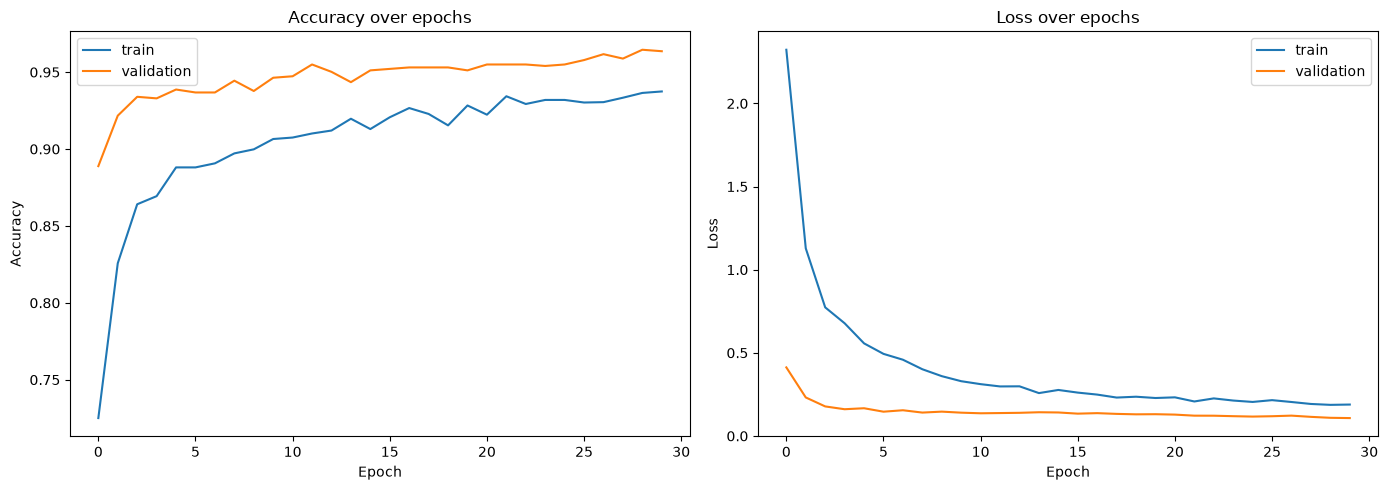

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['binary_accuracy'], label='train')
axes[0].plot(history.history['val_binary_accuracy'], label='validation')
axes[0].set_title('Accuracy over epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('Loss over epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

plt.tight_layout()
plt.show()


#Roc curve

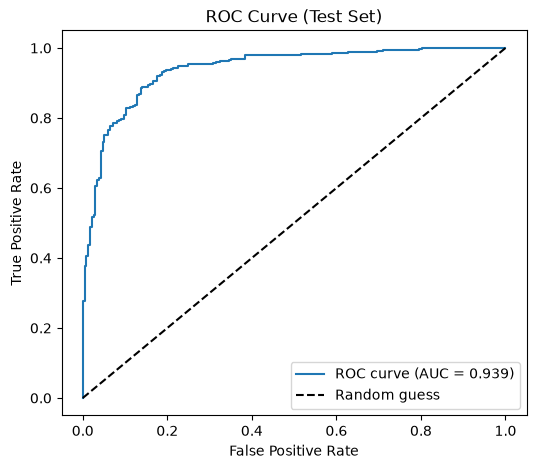

In [28]:
from sklearn.metrics import roc_curve, auc

test_images = open_images_no_aug(test_paths)
y_true = encode_label(test_labels)
y_prob = model.predict(test_images, batch_size=20, verbose=0).ravel()

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_value:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)'); plt.legend()
plt.show()


#model classificationn report

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data

test_images = open_images_no_aug(test_paths)

test_labels_encoded = encode_label(test_labels)

# Predict using the trained model

test_predictions = model.predict(test_images)

# Convert probabilities to 0 or 1

test_predicted_labels = (
    test_predictions >= 0.5
).astype(int).flatten()

# 2. Classification Report

print("Classification Report:")

print(
    classification_report(
        test_labels_encoded,
        test_predicted_labels,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step
Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      0.26      0.42       234
   PNEUMONIA       0.69      1.00      0.82       390

    accuracy                           0.72       624
   macro avg       0.85      0.63      0.62       624
weighted avg       0.81      0.72      0.67       624



#Model confusion Matrics

Confusion Matrix:
[[ 62 172]
 [  0 390]]


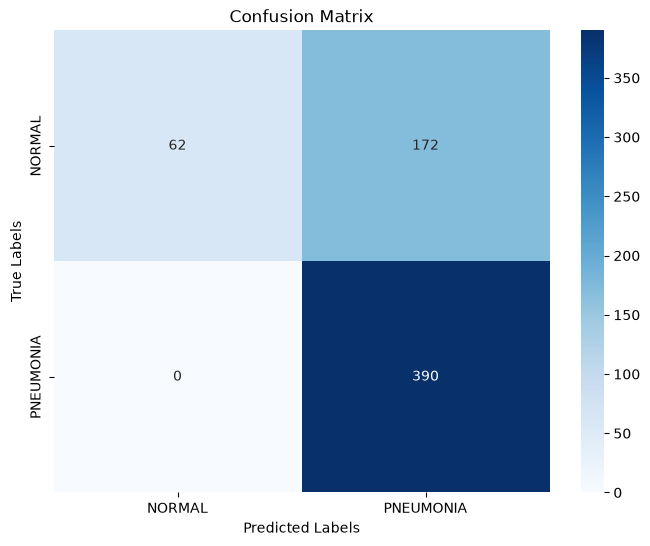

In [17]:
# 3. Confusion Matrix

conf_matrix = confusion_matrix(
    test_labels_encoded,
    test_predicted_labels
)

print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix

plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()